# **EDA...**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load cleaned data
train_df = pd.read_csv('../data/processed/train_data_clean.csv')
test_df = pd.read_csv('../data/processed/test_data_clean.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nColumns: {len(train_df.columns)}")

Train shape: (324824, 53)
Test shape: (81207, 53)

Columns: 53


## 2. Target Distribution Analysis

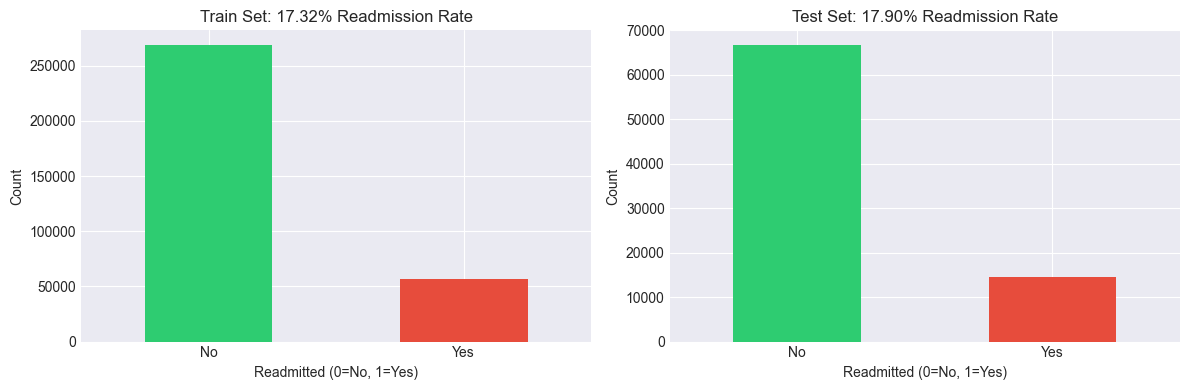

Class imbalance ratio: 5.8:1 (majority:minority)


In [3]:
# Readmission rates
train_rate = train_df['readmitted_30d'].mean()
test_rate = test_df['readmitted_30d'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train distribution
train_df['readmitted_30d'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title(f'Train Set: {train_rate:.2%} Readmission Rate')
axes[0].set_xlabel('Readmitted (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

# Test distribution
test_df['readmitted_30d'].value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title(f'Test Set: {test_rate:.2%} Readmission Rate')
axes[1].set_xlabel('Readmitted (0=No, 1=Yes)')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.savefig('../results/02_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Class imbalance ratio: {1/train_rate:.1f}:1 (majority:minority)")

## 3. Age Distribution by Readmission

In [5]:
# Check all column names
print("All columns:")
print(train_df.columns.tolist())

print("\n\nColumns containing 'age':")
age_cols = [col for col in train_df.columns if 'age' in col.lower()]
print(age_cols)

All columns:
['subject_id', 'hadm_id', 'admittime', 'dischtime', 'gender', 'age', 'race', 'marital_status', 'language', 'insurance', 'admission_type', 'admission_location', 'discharge_location', 'los_hours', 'los_days', 'num_diagnoses', 'cci_mi', 'cci_chf', 'cci_pvd', 'cci_cvd', 'cci_dementia', 'cci_copd', 'cci_diabetes', 'cci_ckd', 'cci_cancer', 'num_lab_tests_24h', 'num_abnormal_labs', 'hemoglobin_min', 'wbc_max', 'creatinine_max', 'sodium_min', 'sodium_max', 'potassium_min', 'potassium_max', 'glucose_min', 'glucose_max', 'num_medications', 'polypharmacy_flag', 'anticoagulant_flag', 'insulin_flag', 'opioid_flag', 'antibiotic_flag', 'num_admissions_last_30d', 'num_admissions_last_90d', 'num_admissions_last_year', 'days_since_last_discharge', 'total_prior_admissions', 'recent_admission_flag', 'frequent_flyer_flag', 'readmitted_30d', 'readmitted_60d', 'readmitted_90d', 'has_prior_admission']


Columns containing 'age':
['age', 'language']


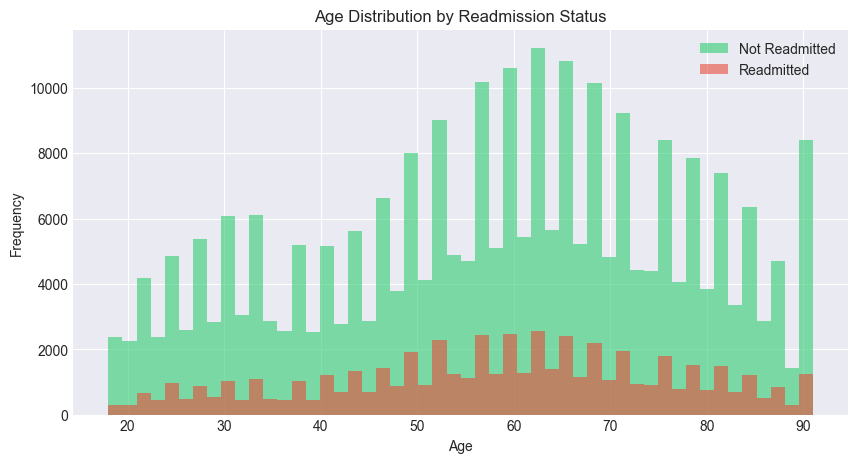

Mean age (Readmitted): 58.2
Mean age (Not Readmitted): 57.9
T-test p-value: 0.0001


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

# Plot age distributions
train_df[train_df['readmitted_30d']==0]['age'].hist(bins=50, alpha=0.6, label='Not Readmitted', ax=ax, color='#2ecc71')
train_df[train_df['readmitted_30d']==1]['age'].hist(bins=50, alpha=0.6, label='Readmitted', ax=ax, color='#e74c3c')

ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.set_title('Age Distribution by Readmission Status')
ax.legend()
plt.savefig('../results/03_age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical test
readmit_ages = train_df[train_df['readmitted_30d']==1]['age']
no_readmit_ages = train_df[train_df['readmitted_30d']==0]['age']

print(f"Mean age (Readmitted): {readmit_ages.mean():.1f}")
print(f"Mean age (Not Readmitted): {no_readmit_ages.mean():.1f}")
print(f"T-test p-value: {stats.ttest_ind(readmit_ages, no_readmit_ages).pvalue:.4f}")

## 4. Length of Stay Analysis

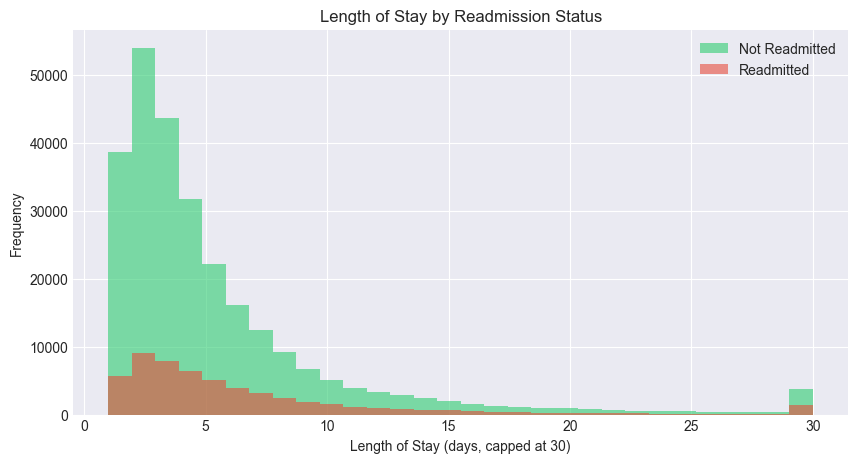

Median LOS (Readmitted): 4.0 days
Median LOS (Not Readmitted): 3.0 days


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

# Plot LOS (capped at 30 days for visualization)
train_df[train_df['readmitted_30d']==0]['los_days'].clip(upper=30).hist(bins=30, alpha=0.6, label='Not Readmitted', ax=ax, color='#2ecc71')
train_df[train_df['readmitted_30d']==1]['los_days'].clip(upper=30).hist(bins=30, alpha=0.6, label='Readmitted', ax=ax, color='#e74c3c')

ax.set_xlabel('Length of Stay (days, capped at 30)')
ax.set_ylabel('Frequency')
ax.set_title('Length of Stay by Readmission Status')
ax.legend()
plt.savefig('../results/04_los_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Stats
print(f"Median LOS (Readmitted): {train_df[train_df['readmitted_30d']==1]['los_days'].median():.1f} days")
print(f"Median LOS (Not Readmitted): {train_df[train_df['readmitted_30d']==0]['los_days'].median():.1f} days")

## 5. Comorbidity Analysis

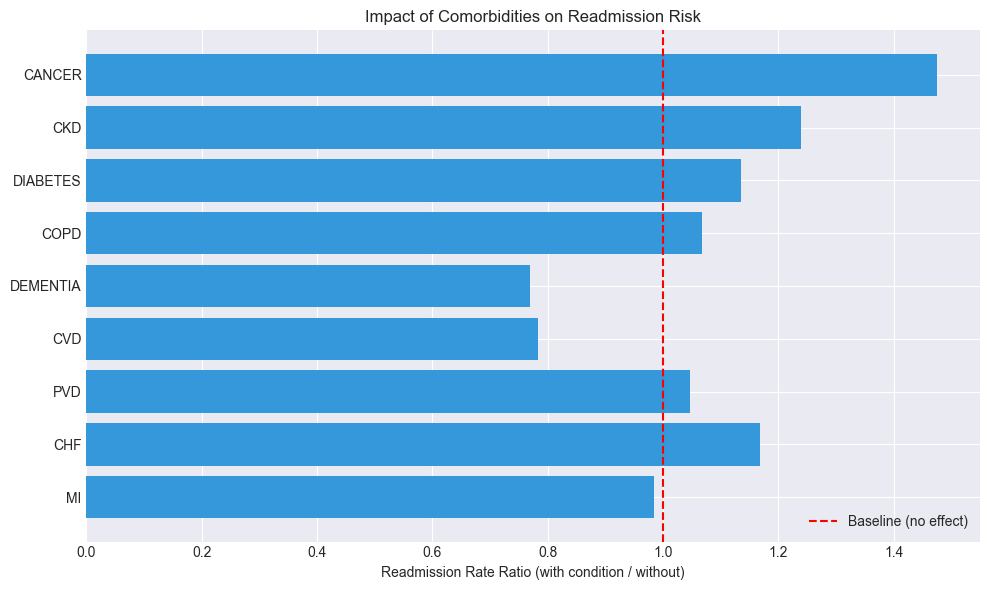

Top 3 comorbidities increasing readmission risk:
  CANCER: 1.48x risk
  CKD: 1.24x risk
  CHF: 1.17x risk


In [9]:
# Charlson Comorbidity Index components
cci_features = ['cci_mi', 'cci_chf', 'cci_pvd', 'cci_cvd', 'cci_dementia', 
                'cci_copd', 'cci_diabetes', 'cci_ckd', 'cci_cancer']

# Calculate readmission rates for each comorbidity
comorbidity_rates = {}
for feature in cci_features:
    if feature in train_df.columns:
        rate_with = train_df[train_df[feature]==1]['readmitted_30d'].mean()
        rate_without = train_df[train_df[feature]==0]['readmitted_30d'].mean()
        comorbidity_rates[feature] = {
            'with': rate_with,
            'without': rate_without,
            'ratio': rate_with / rate_without if rate_without > 0 else 0
        }

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
feature_names = [f.replace('cci_', '').upper() for f in comorbidity_rates.keys()]
ratios = [comorbidity_rates[f]['ratio'] for f in comorbidity_rates.keys()]

bars = ax.barh(feature_names, ratios, color='#3498db')
ax.axvline(x=1.0, color='red', linestyle='--', label='Baseline (no effect)')
ax.set_xlabel('Readmission Rate Ratio (with condition / without)')
ax.set_title('Impact of Comorbidities on Readmission Risk')
ax.legend()
plt.tight_layout()
plt.savefig('../results/05_comorbidity_impact.png', dpi=300, bbox_inches='tight')
plt.show()

# Print top 3
sorted_comorbidities = sorted(comorbidity_rates.items(), key=lambda x: x[1]['ratio'], reverse=True)
print("Top 3 comorbidities increasing readmission risk:")
for feature, data in sorted_comorbidities[:3]:
    print(f"  {feature.replace('cci_', '').upper()}: {data['ratio']:.2f}x risk")

## 6. Historical Admission Patterns

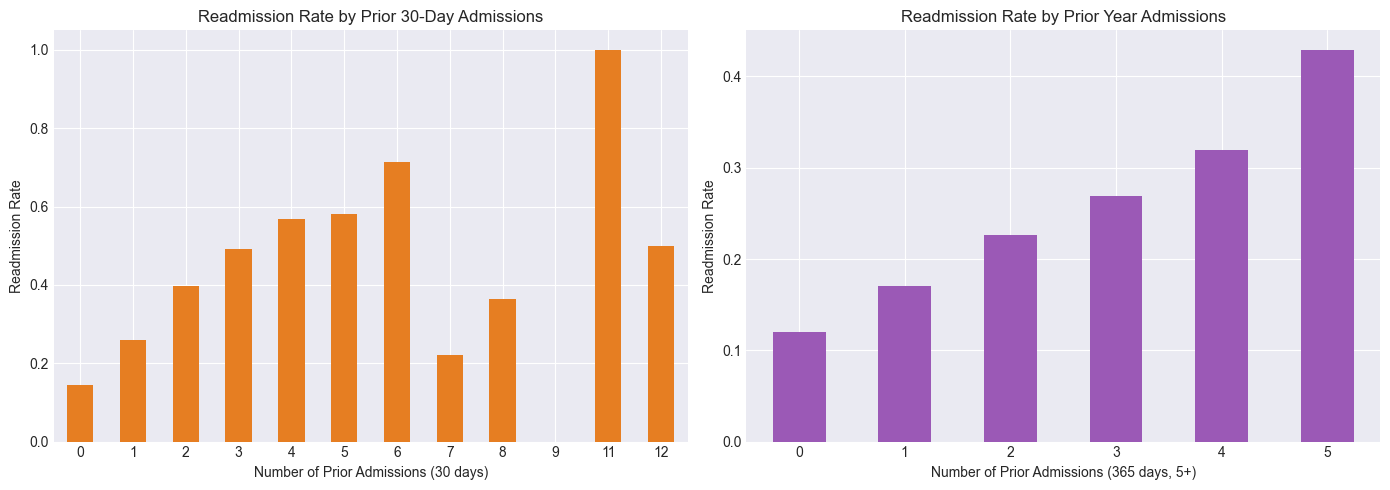

Patients with prior 30-day admission:
  Readmission rate: 28.97%
  Vs. No prior: 14.33%


In [11]:
# Prior admissions impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prior 30-day admissions
if 'num_admissions_last_30d' in train_df.columns:
    prior_30d_grouped = train_df.groupby('num_admissions_last_30d')['readmitted_30d'].mean()
    prior_30d_grouped.plot(kind='bar', ax=axes[0], color='#e67e22')
    axes[0].set_title('Readmission Rate by Prior 30-Day Admissions')
    axes[0].set_xlabel('Number of Prior Admissions (30 days)')
    axes[0].set_ylabel('Readmission Rate')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Prior 365-day admissions (capped at 5+)
if 'num_admissions_last_year' in train_df.columns:
    train_df['prior_365d_capped'] = train_df['num_admissions_last_year'].clip(upper=5)
    prior_365d_grouped = train_df.groupby('prior_365d_capped')['readmitted_30d'].mean()
    prior_365d_grouped.plot(kind='bar', ax=axes[1], color='#9b59b6')
    axes[1].set_title('Readmission Rate by Prior Year Admissions')
    axes[1].set_xlabel('Number of Prior Admissions (365 days, 5+)')
    axes[1].set_ylabel('Readmission Rate')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../results/06_historical_admissions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Patients with prior 30-day admission:")
print(f"  Readmission rate: {train_df[train_df['num_admissions_last_30d']>0]['readmitted_30d'].mean():.2%}")
print(f"  Vs. No prior: {train_df[train_df['num_admissions_last_30d']==0]['readmitted_30d'].mean():.2%}")

## 7. Lab Values - Critical Ranges

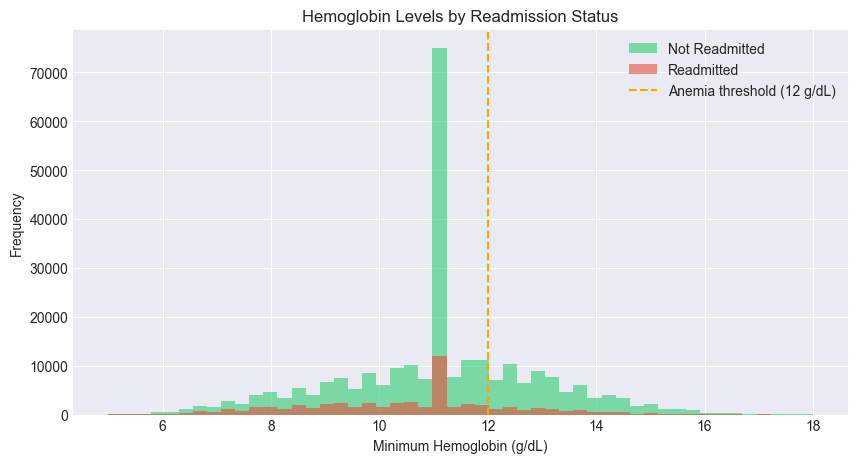

Mean hemoglobin (Readmitted): 10.52
Mean hemoglobin (Not Readmitted): 11.08


In [12]:
# Analyze hemoglobin (anemia indicator)
fig, ax = plt.subplots(figsize=(10, 5))

if 'hemoglobin_min' in train_df.columns:
    train_df[train_df['readmitted_30d']==0]['hemoglobin_min'].hist(bins=50, alpha=0.6, label='Not Readmitted', ax=ax, range=(5, 18), color='#2ecc71')
    train_df[train_df['readmitted_30d']==1]['hemoglobin_min'].hist(bins=50, alpha=0.6, label='Readmitted', ax=ax, range=(5, 18), color='#e74c3c')
    
    # Mark clinical thresholds
    ax.axvline(x=12, color='orange', linestyle='--', label='Anemia threshold (12 g/dL)')
    
    ax.set_xlabel('Minimum Hemoglobin (g/dL)')
    ax.set_ylabel('Frequency')
    ax.set_title('Hemoglobin Levels by Readmission Status')
    ax.legend()
    plt.savefig('../results/07_hemoglobin_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Mean hemoglobin (Readmitted): {train_df[train_df['readmitted_30d']==1]['hemoglobin_min'].mean():.2f}")
    print(f"Mean hemoglobin (Not Readmitted): {train_df[train_df['readmitted_30d']==0]['hemoglobin_min'].mean():.2f}")

## 8. Medication Burden (Polypharmacy)

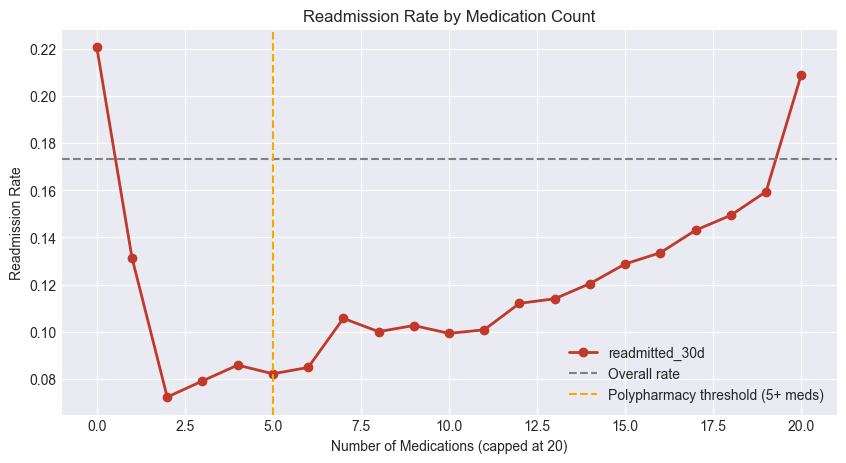

Patients on 5+ medications: 96.7%
Readmission rate (5+ meds): 17.23%
Readmission rate (<5 meds): 19.93%


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

if 'num_medications' in train_df.columns:
    # Cap at 20 for visualization
    train_df['meds_capped'] = train_df['num_medications'].clip(upper=20)
    
    meds_grouped = train_df.groupby('meds_capped')['readmitted_30d'].mean()
    meds_grouped.plot(kind='line', ax=ax, marker='o', color='#c0392b', linewidth=2)
    
    ax.axhline(y=train_df['readmitted_30d'].mean(), color='gray', linestyle='--', label='Overall rate')
    ax.axvline(x=5, color='orange', linestyle='--', label='Polypharmacy threshold (5+ meds)')
    
    ax.set_xlabel('Number of Medications (capped at 20)')
    ax.set_ylabel('Readmission Rate')
    ax.set_title('Readmission Rate by Medication Count')
    ax.legend()
    plt.savefig('../results/08_polypharmacy_impact.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Patients on 5+ medications: {(train_df['num_medications'] >= 5).mean():.1%}")
    print(f"Readmission rate (5+ meds): {train_df[train_df['num_medications'] >= 5]['readmitted_30d'].mean():.2%}")
    print(f"Readmission rate (<5 meds): {train_df[train_df['num_medications'] < 5]['readmitted_30d'].mean():.2%}")

## 9. Feature Correlation with Target

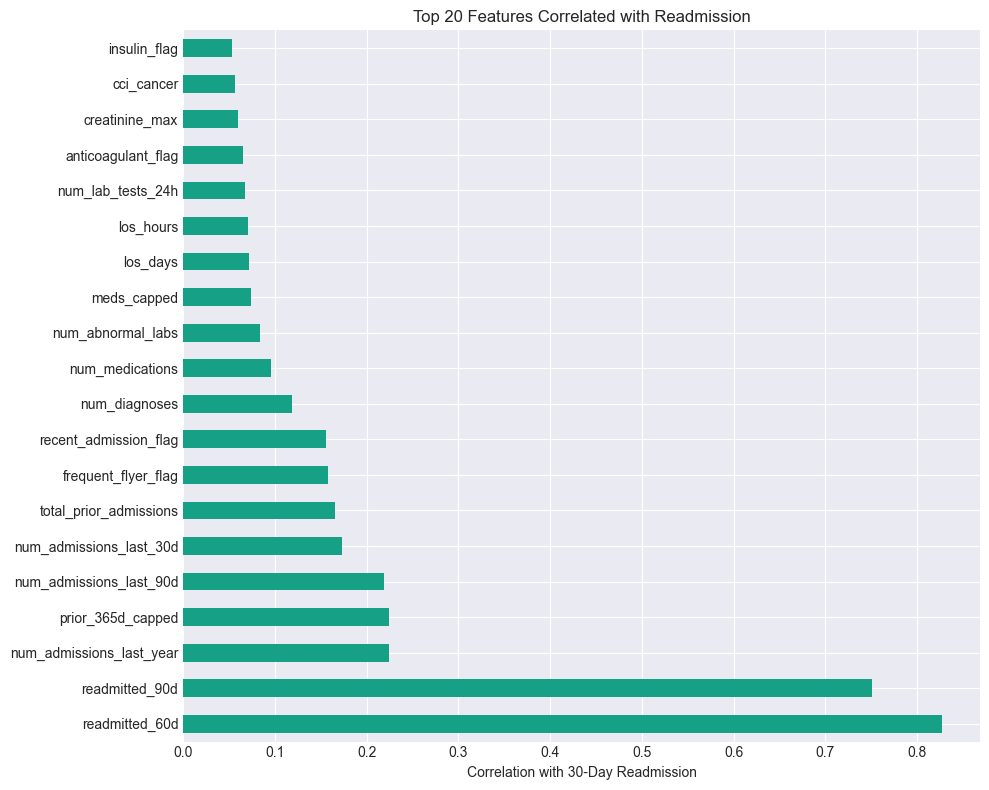

Top 10 positive correlations:
readmitted_60d              0.827100
readmitted_90d              0.751237
num_admissions_last_year    0.224393
prior_365d_capped           0.224284
num_admissions_last_90d     0.219022
num_admissions_last_30d     0.173157
total_prior_admissions      0.165726
frequent_flyer_flag         0.158190
recent_admission_flag       0.156040
num_diagnoses               0.118223
Name: readmitted_30d, dtype: float64

Top 10 negative correlations:
cci_mi                      -0.001567
polypharmacy_flag           -0.006181
wbc_max                     -0.007221
cci_dementia                -0.015784
cci_cvd                     -0.019697
sodium_max                  -0.044332
days_since_last_discharge   -0.048354
sodium_min                  -0.056909
hemoglobin_min              -0.112181
has_prior_admission               NaN
Name: readmitted_30d, dtype: float64


In [14]:
# Select numeric features only
numeric_features = train_df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target and IDs
exclude_cols = ['readmitted_30d', 'subject_id', 'hadm_id', 'admittime']
numeric_features = [f for f in numeric_features if f not in exclude_cols]

# Calculate correlations with target
correlations = train_df[numeric_features + ['readmitted_30d']].corr()['readmitted_30d'].drop('readmitted_30d')
correlations = correlations.sort_values(ascending=False)

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 8))
correlations.head(20).plot(kind='barh', ax=ax, color='#16a085')
ax.set_xlabel('Correlation with 30-Day Readmission')
ax.set_title('Top 20 Features Correlated with Readmission')
plt.tight_layout()
plt.savefig('../results/09_feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top 10 positive correlations:")
print(correlations.head(10))
print("\nTop 10 negative correlations:")
print(correlations.tail(10))

## 10. Summary Statistics Table

In [15]:
# Create summary comparison table
summary_data = {
    'Metric': [
        'Mean Age',
        'Median LOS (days)',
        'Mean Hemoglobin',
        'Mean Total Medications',
        'Prior 30d Admissions Rate',
        'CHF Rate',
        'COPD Rate',
        'Diabetes Rate'
    ],
    'Not Readmitted': [
        train_df[train_df['readmitted_30d']==0]['age'].mean(),
        train_df[train_df['readmitted_30d']==0]['los_days'].median(),
        train_df[train_df['readmitted_30d']==0]['hemoglobin_min'].mean() if 'hemoglobin_min' in train_df.columns else np.nan,
        train_df[train_df['readmitted_30d']==0]['num_medications'].mean() if 'num_medications' in train_df.columns else np.nan,
        (train_df[train_df['readmitted_30d']==0]['num_admissions_last_30d'] > 0).mean() if 'num_admissions_last_30d' in train_df.columns else np.nan,
        train_df[train_df['readmitted_30d']==0]['cci_chf'].mean() if 'cci_chf' in train_df.columns else np.nan,
        train_df[train_df['readmitted_30d']==0]['cci_copd'].mean() if 'cci_copd' in train_df.columns else np.nan,
        train_df[train_df['readmitted_30d']==0]['cci_diabetes'].mean() if 'cci_diabetes' in train_df.columns else np.nan,
    ],
    'Readmitted': [
        train_df[train_df['readmitted_30d']==1]['age'].mean(),
        train_df[train_df['readmitted_30d']==1]['los_days'].median(),
        train_df[train_df['readmitted_30d']==1]['hemoglobin_min'].mean() if 'hemoglobin_min' in train_df.columns else np.nan,
        train_df[train_df['readmitted_30d']==1]['num_medications'].mean() if 'num_medications' in train_df.columns else np.nan,
        (train_df[train_df['readmitted_30d']==1]['num_admissions_last_30d'] > 0).mean() if 'num_admissions_last_30d' in train_df.columns else np.nan,
        train_df[train_df['readmitted_30d']==1]['cci_chf'].mean() if 'cci_chf' in train_df.columns else np.nan,
        train_df[train_df['readmitted_30d']==1]['cci_copd'].mean() if 'cci_copd' in train_df.columns else np.nan,
        train_df[train_df['readmitted_30d']==1]['cci_diabetes'].mean() if 'cci_diabetes' in train_df.columns else np.nan,
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Difference'] = summary_df['Readmitted'] - summary_df['Not Readmitted']

print("="*70)
print("SUMMARY: Readmitted vs Not Readmitted Patients")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)

# Save to CSV for report
summary_df.to_csv('../results/10_summary_statistics.csv', index=False)

SUMMARY: Readmitted vs Not Readmitted Patients
                   Metric  Not Readmitted  Readmitted  Difference
                 Mean Age       57.876189   58.209194    0.333005
        Median LOS (days)        3.000000    4.000000    1.000000
          Mean Hemoglobin       11.075759   10.515771   -0.559987
   Mean Total Medications       23.087422   26.744676    3.657254
Prior 30d Admissions Rate        0.175470    0.341718    0.166248
                 CHF Rate        0.083621    0.099371    0.015750
                COPD Rate        0.092624    0.099584    0.006960
            Diabetes Rate        0.123796    0.141572    0.017776
